# Foundations of Principal Component Analysis (PCA)

This notebook will guide you through the essential mathematical and statistical concepts required to fully understand Principal Component Analysis (PCA). We will cover:

1.  **Standard Deviation & Variance**: Understanding data spread.
2.  **Covariance**: Exploring relationships between variables.
3.  **Matrices & Linear Transformations**: How data is manipulated and reshaped.
4.  **Eigenvectors & Eigenvalues**: The special directions and magnitudes of transformations.

Each section will include a simplified theoretical explanation and practical Python code with visualizations to solidify your understanding.

## 1. Standard Deviation & Variance (The Spread)

Before we can reduce dimensions, we need to understand how data is spread out.

*   **Standard Deviation ($\\sigma$)**: This tells you how far, on average, your data points are from the mean (the center). A small standard deviation means data points are close to the mean, while a large one means they are spread far apart.

*   **Variance ($\\sigma^2$)**: This is simply the standard deviation squared. It provides a measure of the spread of data points from the mean. In Machine Learning, especially for PCA, **variance is often equated with information**. A variable with zero variance (all values are the same) provides no information to distinguish data points.

Let's visualize this with a simple dataset.

<>:26: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:38: SyntaxWarning: invalid escape sequence '\s'
<>:38: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:38: SyntaxWarning: invalid escape sequence '\s'
<>:38: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1072/1656844855.py:26: SyntaxWarning: invalid escape sequence '\s'
  axes[0].set_title(f'Data 1 (Small Spread)\n $\sigma$={std1:.2f}, $\sigma^2$={var1:.2f}')
/tmp/ipykernel_1072/1656844855.py:26: SyntaxWarning: invalid escape sequence '\s'
  axes[0].set_title(f'Data 1 (Small Spread)\n $\sigma$={std1:.2f}, $\sigma^2$={var1:.2f}')
/tmp/ipykernel_1072/1656844855.py:33: Synt

Data 1 (Std Dev=1.06, Var=1.12): Mean=-0.06, Std Dev=1.06, Variance=1.12
Data 2 (Std Dev=2.76, Var=7.60): Mean=-0.35, Std Dev=2.76, Variance=7.60
Data 3 (Std Dev=0.00, Var=0.00): Mean=5.00, Std Dev=0.00, Variance=0.00


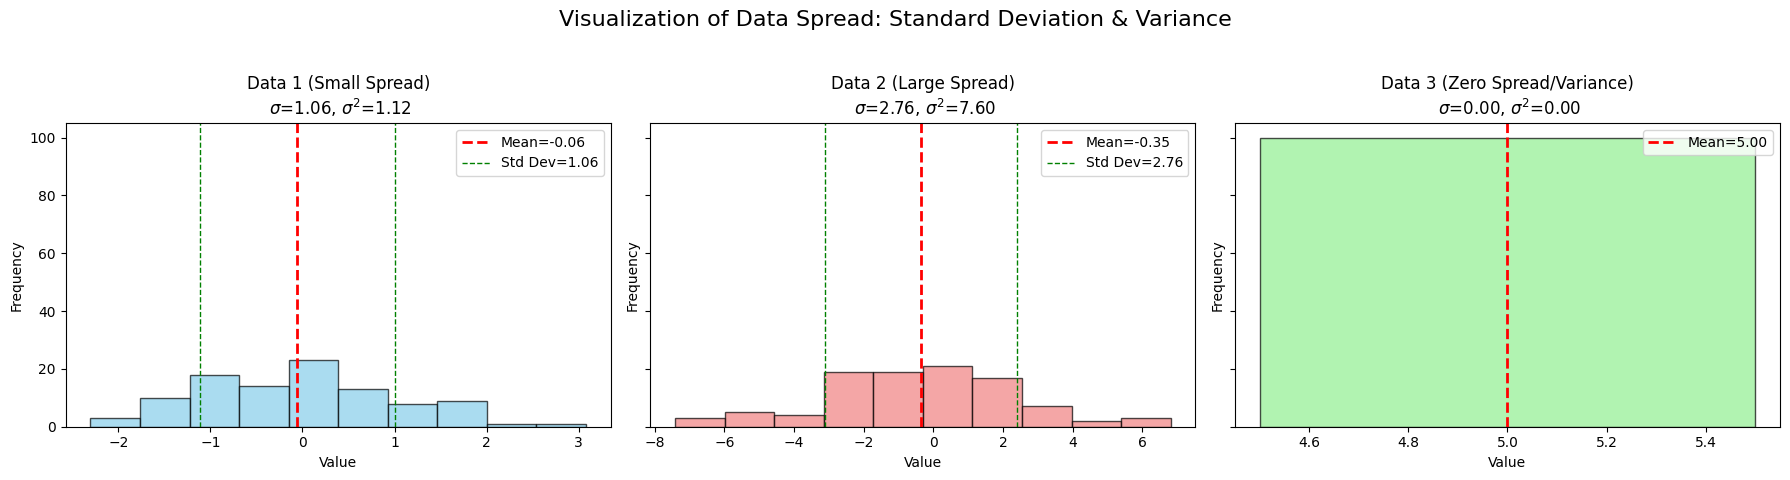

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Generate some sample data
data1 = np.random.normal(loc=0, scale=1, size=100) # Mean 0, Std Dev 1
data2 = np.random.normal(loc=0, scale=3, size=100) # Mean 0, Std Dev 3
data3 = np.full(100, 5) # All values are 5, zero variance

# Calculate mean, standard deviation, and variance
mean1, std1, var1 = np.mean(data1), np.std(data1), np.var(data1)
mean2, std2, var2 = np.mean(data2), np.std(data2), np.var(data2)
mean3, std3, var3 = np.mean(data3), np.std(data3), np.var(data3)

print(f"Data 1 (Std Dev={std1:.2f}, Var={var1:.2f}): Mean={mean1:.2f}, Std Dev={std1:.2f}, Variance={var1:.2f}")
print(f"Data 2 (Std Dev={std2:.2f}, Var={var2:.2f}): Mean={mean2:.2f}, Std Dev={std2:.2f}, Variance={var2:.2f}")
print(f"Data 3 (Std Dev={std3:.2f}, Var={var3:.2f}): Mean={mean3:.2f}, Std Dev={std3:.2f}, Variance={var3:.2f}")

# Create histograms to visualize spread
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Visualization of Data Spread: Standard Deviation & Variance', fontsize=16)

axes[0].hist(data1, bins=10, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].axvline(mean1, color='red', linestyle='dashed', linewidth=2, label=f'Mean={mean1:.2f}')
axes[0].axvline(mean1 - std1, color='green', linestyle='dashed', linewidth=1, label=f'Std Dev={std1:.2f}')
axes[0].axvline(mean1 + std1, color='green', linestyle='dashed', linewidth=1)
axes[0].set_title(f'Data 1 (Small Spread)\n $\sigma$={std1:.2f}, $\sigma^2$={var1:.2f}')
axes[0].legend()

axes[1].hist(data2, bins=10, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1].axvline(mean2, color='red', linestyle='dashed', linewidth=2, label=f'Mean={mean2:.2f}')
axes[1].axvline(mean2 - std2, color='green', linestyle='dashed', linewidth=1, label=f'Std Dev={std2:.2f}')
axes[1].axvline(mean2 + std2, color='green', linestyle='dashed', linewidth=1)
axes[1].set_title(f'Data 2 (Large Spread)\n $\sigma$={std2:.2f}, $\sigma^2$={var2:.2f}')
axes[1].legend()

axes[2].hist(data3, bins=1, alpha=0.7, color='lightgreen', edgecolor='black') # 1 bin for constant data
axes[2].axvline(mean3, color='red', linestyle='dashed', linewidth=2, label=f'Mean={mean3:.2f}')
axes[2].set_title(f'Data 3 (Zero Spread/Variance)\n $\sigma$={std3:.2f}, $\sigma^2$={var3:.2f}')
axes[2].legend()

for ax in axes:
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 2. Covariance (The Relationship)

While variance looks at the spread of a single variable, **covariance** looks at two variables at the same time to see how they move together.

*   **Positive Covariance**: If $X$ increases, $Y$ also tends to increase (e.g., hours studied and exam score). The points on a scatter plot would generally form an upward-sloping cloud.
*   **Negative Covariance**: If $X$ increases, $Y$ tends to decrease (e.g., car mileage and car price). The points would generally form a downward-sloping cloud.
*   **Zero Covariance**: $X$ and $Y$ have no consistent linear relationship. The points would be scattered without a clear pattern.

When you have a dataset with many features, you calculate a **Covariance Matrix**. This is a square matrix where:

*   Diagonal elements: Variance of each feature ($Cov(X_i, X_i) = Var(X_i)$).
*   Off-diagonal elements: Covariance between two different features ($Cov(X_i, X_j)$).

This matrix is a crucial mathematical blueprint PCA uses to understand the underlying relationships and shape of your data.

Positive Covariance Matrix:
[[0.78 0.56]
 [0.56 0.74]]

Negative Covariance Matrix:
[[ 1.11 -0.79]
 [-0.79  0.99]]

Zero Covariance Matrix:
[[1.05 0.09]
 [0.09 0.93]]



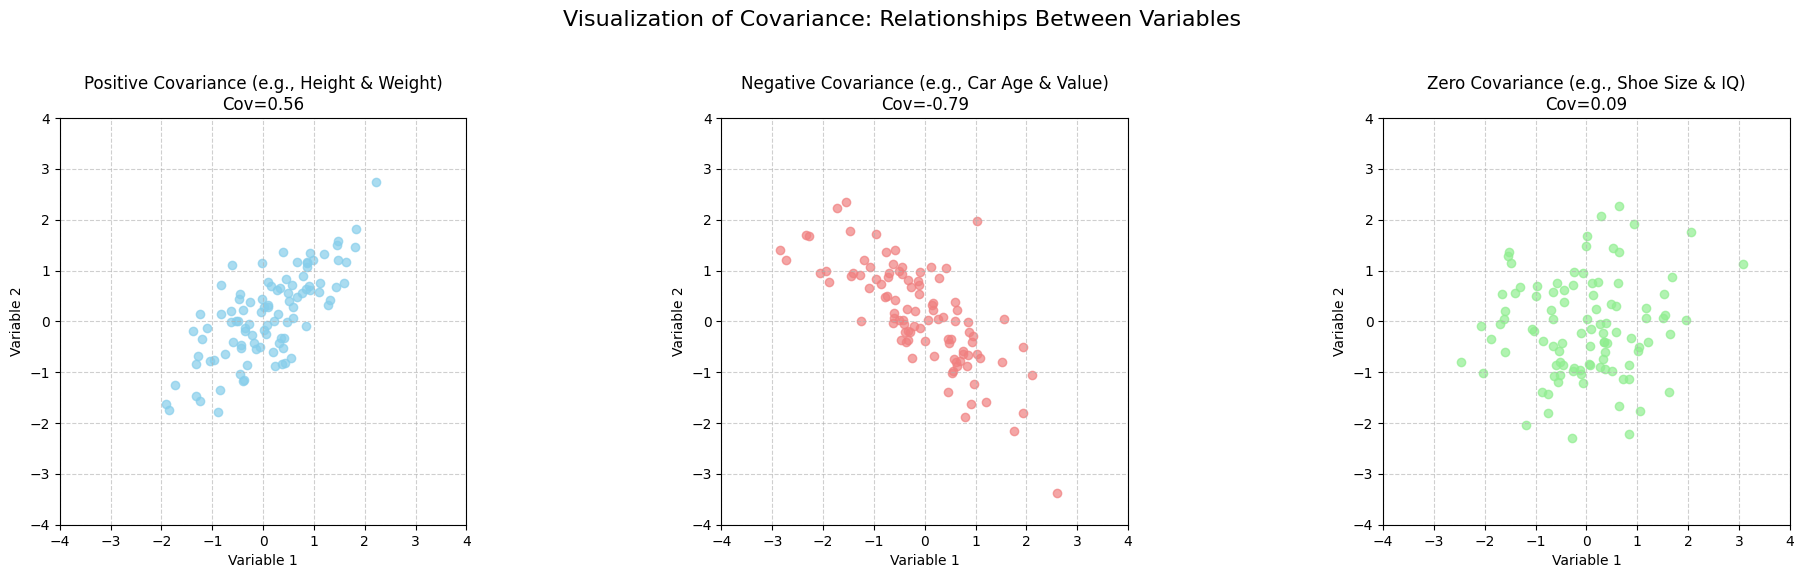

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Generate 2D data with different covariance patterns
np.random.seed(42)

# Positive Covariance
data_pos_cov = np.random.multivariate_normal(mean=[0, 0], cov=[[1, 0.8], [0.8, 1]], size=100)

# Negative Covariance
data_neg_cov = np.random.multivariate_normal(mean=[0, 0], cov=[[1, -0.7], [-0.7, 1]], size=100)

# Zero Covariance (approximately, as it's random)
data_zero_cov = np.random.multivariate_normal(mean=[0, 0], cov=[[1, 0], [0, 1]], size=100)

# Calculate covariance matrices
cov_pos = np.cov(data_pos_cov, rowvar=False) # rowvar=False means columns are variables
cov_neg = np.cov(data_neg_cov, rowvar=False)
cov_zero = np.cov(data_zero_cov, rowvar=False)

print(f"Positive Covariance Matrix:\n{cov_pos.round(2)}\n")
print(f"Negative Covariance Matrix:\n{cov_neg.round(2)}\n")
print(f"Zero Covariance Matrix:\n{cov_zero.round(2)}\n")

# Create scatter plots to visualize covariance
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Visualization of Covariance: Relationships Between Variables', fontsize=16)

axes[0].scatter(data_pos_cov[:, 0], data_pos_cov[:, 1], alpha=0.7, color='skyblue')
axes[0].set_title(f'Positive Covariance (e.g., Height & Weight)\nCov={cov_pos[0,1]:.2f}')

axes[1].scatter(data_neg_cov[:, 0], data_neg_cov[:, 1], alpha=0.7, color='lightcoral')
axes[1].set_title(f'Negative Covariance (e.g., Car Age & Value)\nCov={cov_neg[0,1]:.2f}')

axes[2].scatter(data_zero_cov[:, 0], data_zero_cov[:, 1], alpha=0.7, color='lightgreen')
axes[2].set_title(f'Zero Covariance (e.g., Shoe Size & IQ)\nCov={cov_zero[0,1]:.2f}')

for ax in axes:
    ax.set_xlabel('Variable 1')
    ax.set_ylabel('Variable 2')
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 3. Matrices & Linear Transformations (The Reshaping of Space)

A **matrix** is a rectangular array of numbers, symbols, or expressions arranged in rows and columns. In linear algebra, matrices are powerful tools that can represent **linear transformations**.

A **linear transformation** is essentially a function that maps vectors from one space to another, with two key properties:

1.  **Origin remains fixed**: The point (0,0) never moves.
2.  **Grid lines remain parallel and evenly spaced**: Straight lines remain straight, and parallel lines remain parallel.

Think of it as 'morphing' space. Scaling (stretching/shrinking), rotation, and shearing (slanting) are all examples of linear transformations. Every linear transformation in 2D can be represented by a 2x2 matrix.

When you multiply a vector by a matrix, you are applying a linear transformation to that vector. If you apply the same transformation to all vectors in a space (like our data points), you transform the entire space.

**How a Matrix Represents a Transformation:**

For a 2D space, any linear transformation is completely defined by where it moves the two standard basis vectors: $\hat{i} = \begin{pmatrix} 1 \\ 0 \end{pmatrix}$ and $\hat{j} = \begin{pmatrix} 0 \\ 1 \end{pmatrix}$.

If the transformation moves $\hat{i}$ to $\begin{pmatrix} a \\ c \end{pmatrix}$ and $\hat{j}$ to $\begin{pmatrix} b \\ d \end{pmatrix}$, then the transformation matrix $T$ is simply these two transformed vectors placed side-by-side as columns:

$$ T = \begin{pmatrix} a & b \\ c & d \end{pmatrix} $$

To apply this transformation to any vector $\vec{v} = \begin{pmatrix} x \\ y \end{pmatrix}$, you perform a matrix multiplication:

$$ T\vec{v} = \begin{pmatrix} a & b \\ c & d \end{pmatrix} \begin{pmatrix} x \\ y \end{pmatrix} = \begin{pmatrix} ax + by \\ cx + dy \end{pmatrix} $$

This is the fundamental operation behind how PCA 'reshapes' or 'rotates' your data to find new axes.

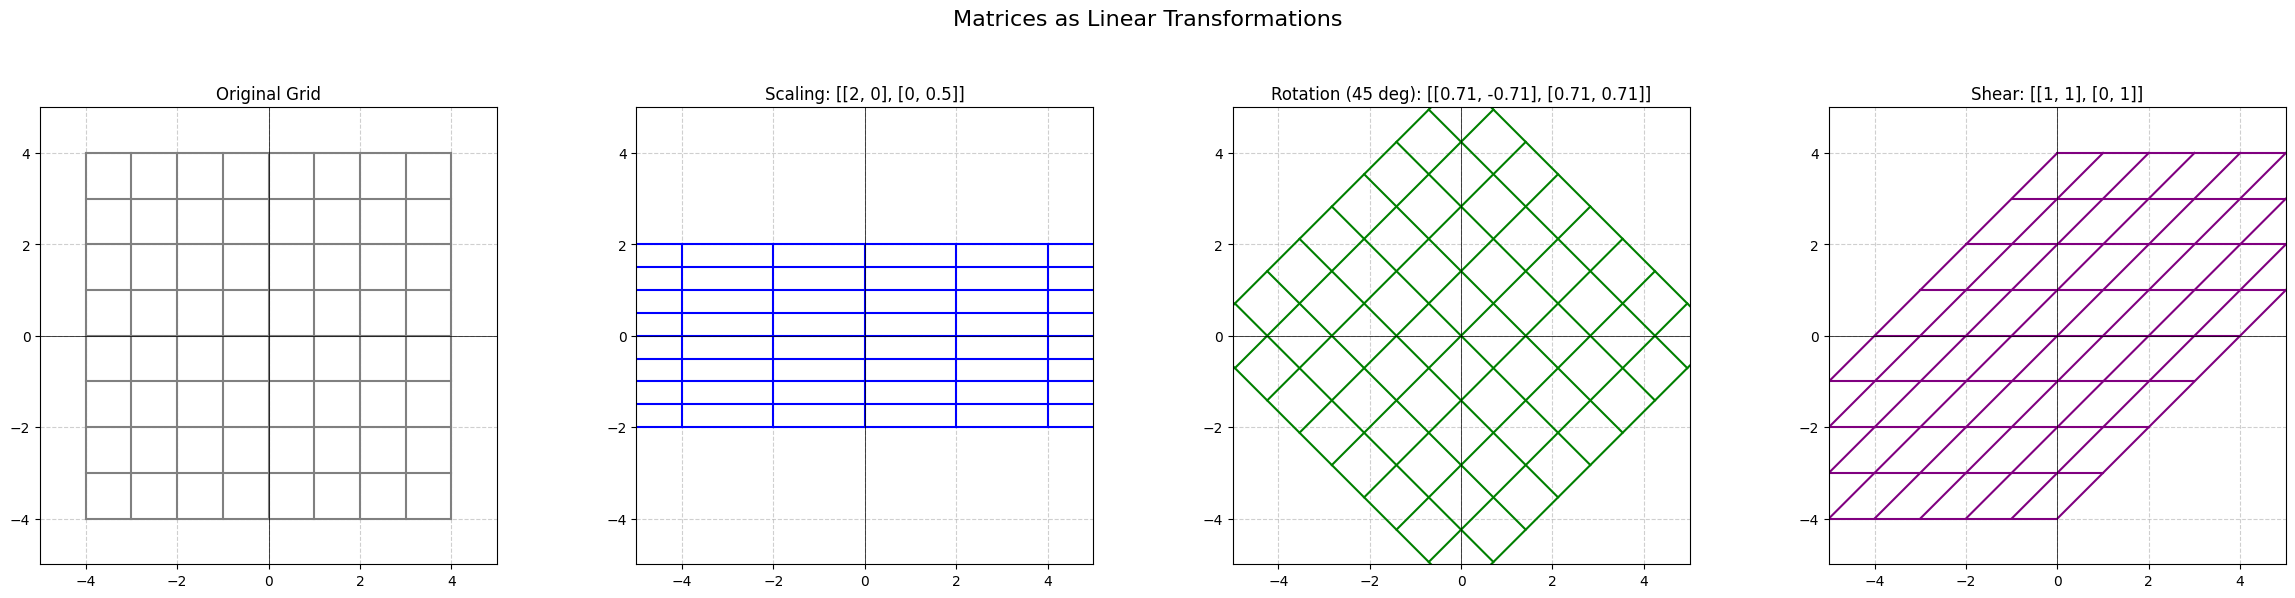

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Function to plot a 2D grid (re-defined for fresh start)
def plot_grid(ax, x_range, y_range, transform_matrix=None, color='gray', linestyle='-') :
    for i in x_range:
        start_point = np.array([i, y_range[0]])
        end_point = np.array([i, y_range[-1]])
        if transform_matrix is not None:
            start_point = transform_matrix @ start_point
            end_point = transform_matrix @ end_point
        ax.plot([start_point[0], end_point[0]], [start_point[1], end_point[1]], color=color, linestyle=linestyle)

    for j in y_range:
        start_point = np.array([x_range[0], j])
        end_point = np.array([x_range[-1], j])
        if transform_matrix is not None:
            start_point = transform_matrix @ start_point
            end_point = transform_matrix @ end_point
        ax.plot([start_point[0], end_point[0]], [start_point[1], end_point[1]], color=color, linestyle=linestyle)

    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle='--', alpha=0.6)


# --- Visualize different transformations ---
x_range = np.arange(-4, 5)
y_range = np.arange(-4, 5)

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle('Matrices as Linear Transformations', fontsize=16)

# Original Grid
plot_grid(axes[0], x_range, y_range)
axes[0].set_title('Original Grid')

# Scaling Transformation
scaling_matrix = np.array([[2, 0], [0, 0.5]])
plot_grid(axes[1], x_range, y_range, transform_matrix=scaling_matrix, color='blue')
axes[1].set_title('Scaling: [[2, 0], [0, 0.5]]')

# Rotation Transformation (45 degrees counter-clockwise)
theta = np.pi / 4 # 45 degrees
rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
plot_grid(axes[2], x_range, y_range, transform_matrix=rotation_matrix, color='green')
axes[2].set_title(f'Rotation (45 deg): [[{np.cos(theta):.2f}, {-np.sin(theta):.2f}], [{np.sin(theta):.2f}, {np.cos(theta):.2f}]]')

# Shearing Transformation
shear_matrix = np.array([[1, 1], [0, 1]])
plot_grid(axes[3], x_range, y_range, transform_matrix=shear_matrix, color='purple')
axes[3].set_title('Shear: [[1, 1], [0, 1]]')

plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

## 4. Eigenvectors & Eigenvalues (The Skeleton)

Now we arrive at two of the most critical concepts for understanding PCA: **Eigenvectors** and **Eigenvalues**.

Imagine a linear transformation morphing space. Most vectors will be stretched, squished, and rotated in some complex way. But there are special vectors, the **eigenvectors**, that exhibit a unique behavior:

*   **Eigenvectors (The Direction)**: These are the special vectors that, when a linear transformation is applied to them, only get stretched or squished (scaled), but their *direction* does not change. They simply lie on the 'axis' of the transformation. They point in the directions where the transformation acts only by scaling.

*   **Eigenvalues (The Magnitude)**: This is a scalar value (a single number) attached to each eigenvector. It tells you *how much* the eigenvector is stretched or squished by the transformation. A larger eigenvalue means a greater scaling effect along that eigenvector's direction.

Mathematically, for a square matrix $A$ (which represents a linear transformation), a non-zero vector $\vec{v}$ is an eigenvector of $A$ if there exists a scalar $\lambda$ (the eigenvalue) such that:

$$ A\vec{v} = \lambda\vec{v} $$

**In the context of PCA:**

When we apply this concept to the **covariance matrix** of our data, the eigenvectors point in the directions (the Principal Components) where our data has the most variance. The corresponding eigenvalues tell us exactly how much variance exists along those principal components. The eigenvector with the largest eigenvalue is PC1 (most variance), the next largest is PC2, and so on.

Transformation Matrix A:
[[2 1]
 [1 2]]

Eigenvalues: [3. 1.]
Eigenvectors (each column is an eigenvector):
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


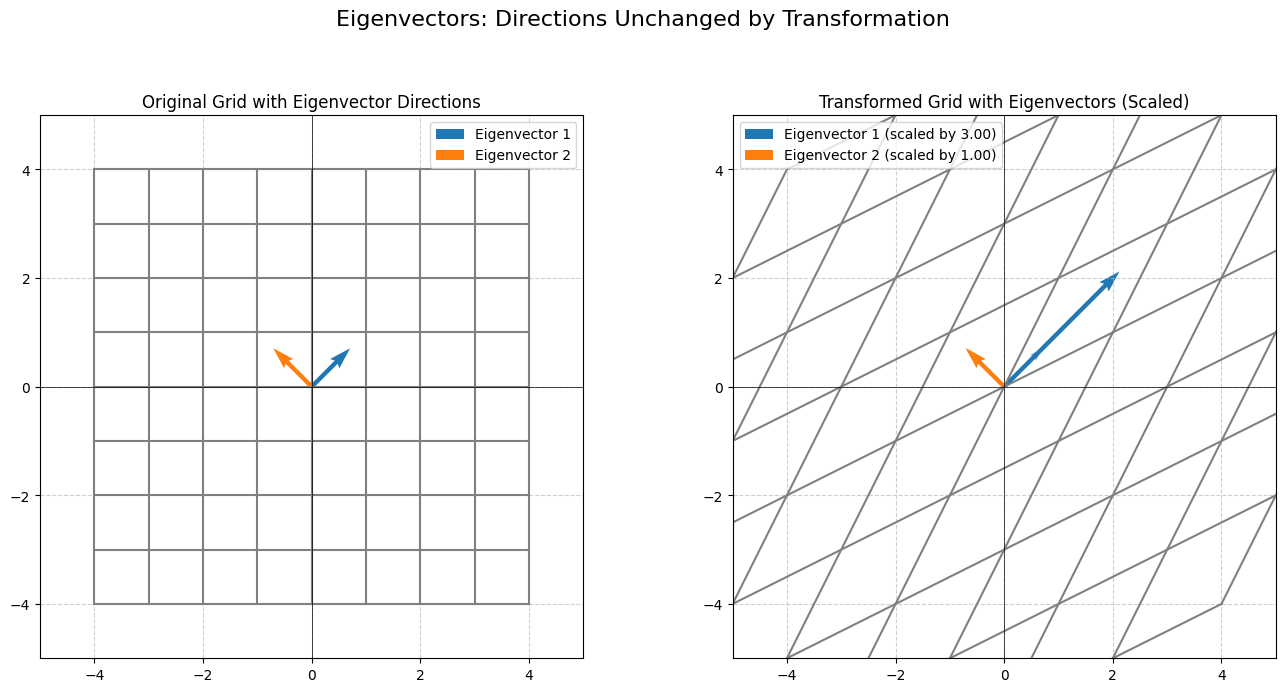

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure plot_grid function is defined in this session (or run previous cell)
# Re-define plot_grid here for full independence if user skips cells
def plot_grid(ax, x_range, y_range, transform_matrix=None, color='gray', linestyle='-') :
    for i in x_range:
        start_point = np.array([i, y_range[0]])
        end_point = np.array([i, y_range[-1]])
        if transform_matrix is not None:
            start_point = transform_matrix @ start_point
            end_point = transform_matrix @ end_point
        ax.plot([start_point[0], end_point[0]], [start_point[1], end_point[1]], color=color, linestyle=linestyle)

    for j in y_range:
        start_point = np.array([x_range[0], j])
        end_point = np.array([x_range[-1], j])
        if transform_matrix is not None:
            start_point = transform_matrix @ start_point
            end_point = transform_matrix @ end_point
        ax.plot([start_point[0], end_point[0]], [start_point[1], end_point[1]], color=color, linestyle=linestyle)

    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle='--', alpha=0.6)


# Define a simple transformation matrix
A = np.array([[2, 1], [1, 2]])

# Calculate eigenvectors and eigenvalues
eigenvalues, eigenvectors = np.linalg.eig(A)

print(f"Transformation Matrix A:\n{A}")
print(f"\nEigenvalues: {eigenvalues}")
print(f"Eigenvectors (each column is an eigenvector):\n{eigenvectors}")

# Plotting the transformation and eigenvectors
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('Eigenvectors: Directions Unchanged by Transformation', fontsize=16)

origin = np.array([0, 0])
x_range = np.arange(-4, 5)
y_range = np.arange(-4, 5)

# --- Left Plot: Original Grid and Eigenvectors ---
plot_grid(axes[0], x_range, y_range)
axes[0].set_title('Original Grid with Eigenvector Directions')

# Plot eigenvectors on original grid
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    axes[0].quiver(*origin, v[0], v[1], angles='xy', scale_units='xy', scale=1,
                   color=f'C{i}', width=0.008, label=f'Eigenvector {i+1}')
axes[0].legend()

# --- Right Plot: Transformed Grid and Scaled Eigenvectors ---
plot_grid(axes[1], x_range, y_range, transform_matrix=A)
axes[1].set_title('Transformed Grid with Eigenvectors (Scaled)')

# Plot transformed eigenvectors (they should still align with their original directions)
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    lambda_val = eigenvalues[i]

    # The transformed eigenvector is A @ v, which should be lambda * v
    transformed_v = A @ v

    # Plot the original eigenvector (dashed) and the scaled eigenvector
    axes[1].quiver(*origin, v[0], v[1], angles='xy', scale_units='xy', scale=1,
                   color=f'C{i}', width=0.005, linestyle='--', alpha=0.6)
    axes[1].quiver(*origin, transformed_v[0], transformed_v[1], angles='xy', scale_units='xy', scale=1,
                   color=f'C{i}', width=0.008, label=f'Eigenvector {i+1} (scaled by {lambda_val:.2f})')
axes[1].legend()

for ax in axes:
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

## 4. PCA: Geometric Intuition (The Rotation and Projection)

Imagine your data points scattered in a multi-dimensional space. PCA's goal is to find a new set of axes (or dimensions) for your data such that:

1.  **Maximum Variance:** The first new axis (Principal Component 1, or PC1) captures the direction where your data varies the most.
2.  **Orthogonality:** Each subsequent new axis (PC2, PC3, etc.) is perpendicular (orthogonal) to the previous ones and captures the next greatest amount of variance.

Think of it as looking at a 3D cloud of points. If you want to view it in 2D while losing the least amount of information, you'd rotate it until its "flattest" side is facing you. That flat side represents the plane spanned by your principal components.

**The Process, Visually:**

*   **Centering:** First, PCA shifts the origin of your data to its mean. This is crucial because variance and covariance are calculated relative to the mean.
*   **Finding PC1:** It then finds the line that best fits the data in a way that minimizes the average squared distance from each point to the line (or, equivalently, maximizes the variance of the projected points along that line). This line is your first Principal Component.
*   **Finding PC2 (and beyond):** For the second component, it finds a line perpendicular to PC1 that captures the next most variance. In 3D, this would be a plane, and so on.
*   **Projection:** Once these new axes are found, you can project your original data onto these new axes. If you choose to keep only the first few principal components, you effectively reduce the dimensionality of your data while retaining as much of the original variance (information) as possible.

Let's visualize this with a simple 2D dataset that has some correlation.

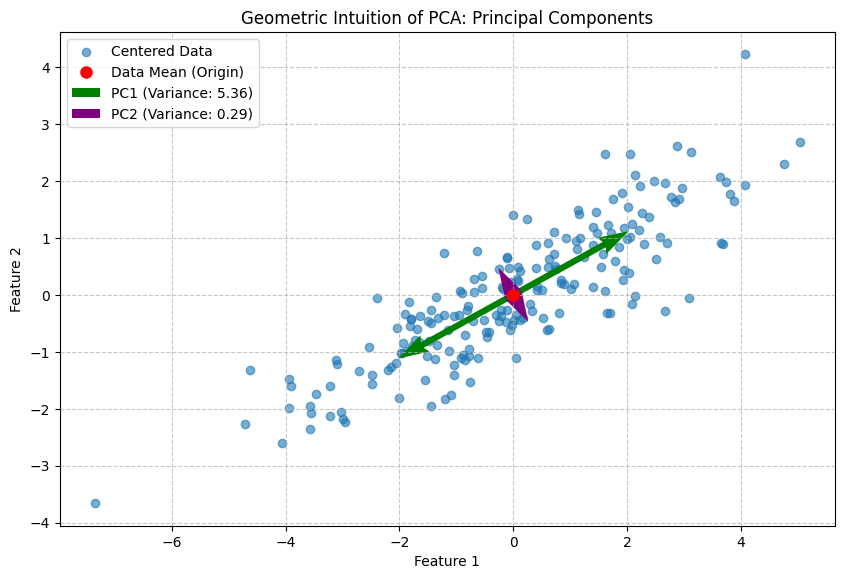

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Generate correlated 2D data ---
np.random.seed(42)

# Create some correlated data
X_original = np.random.randn(200, 2)
# Apply a transformation to make it correlated and spread out
transformation = np.array([[2, 0.8], [0.8, 1]])
X_correlated = X_original @ transformation

# --- 2. Center the data ---
mean_vec = np.mean(X_correlated, axis=0)
X_centered = X_correlated - mean_vec

# --- 3. Calculate Covariance Matrix ---
cov_matrix = np.cov(X_centered, rowvar=False) # rowvar=False means columns are variables

# --- 4. Find Eigenvectors and Eigenvalues of the Covariance Matrix ---
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort eigenvectors by eigenvalues in descending order
sort_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sort_indices]
eigenvectors = eigenvectors[:, sort_indices]

pc1 = eigenvectors[:, 0] # First principal component (direction of max variance)
pc2 = eigenvectors[:, 1] # Second principal component (orthogonal to PC1)

# --- 5. Visualize the data and Principal Components ---
fig, ax = plt.subplots(figsize=(10, 8))

# Plot original centered data points
ax.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.6, label='Centered Data')

# Plot the mean (origin of centered data)
ax.plot(0, 0, 'o', color='red', markersize=8, label='Data Mean (Origin)')

# Plot PC1 (scaled by its eigenvalue for visualization)
ax.quiver(0, 0, pc1[0] * np.sqrt(eigenvalues[0]), pc1[1] * np.sqrt(eigenvalues[0]),
          angles='xy', scale_units='xy', scale=1, color='green', width=0.008,
          label=f'PC1 (Variance: {eigenvalues[0]:.2f})')
ax.quiver(0, 0, -pc1[0] * np.sqrt(eigenvalues[0]), -pc1[1] * np.sqrt(eigenvalues[0]),
          angles='xy', scale_units='xy', scale=1, color='green', width=0.008)

# Plot PC2 (scaled by its eigenvalue)
ax.quiver(0, 0, pc2[0] * np.sqrt(eigenvalues[1]), pc2[1] * np.sqrt(eigenvalues[1]),
          angles='xy', scale_units='xy', scale=1, color='purple', width=0.008,
          label=f'PC2 (Variance: {eigenvalues[1]:.2f})')
ax.quiver(0, 0, -pc2[0] * np.sqrt(eigenvalues[1]), -pc2[1] * np.sqrt(eigenvalues[1]),
          angles='xy', scale_units='xy', scale=1, color='purple', width=0.008)

ax.set_title('Geometric Intuition of PCA: Principal Components')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_aspect('equal', adjustable='box')
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend()
plt.show()

# --- 6. Project data onto PC1 and PC2 (if desired) ---
# This is how dimensionality reduction happens
# projected_data = X_centered @ eigenvectors
# print(f"\nProjected data (first 5 rows):\n{projected_data[:5, :]}")

## 5. PCA: Mathematical Steps (The Matrix Algebra)

Let's formalize the steps involved in Principal Component Analysis. We'll use our understanding of variance, covariance, and eigenvectors/eigenvalues.

### Recap: Variance and Covariance

*   **Variance** ($\sigma^2$): Measures the spread of a single variable from its mean. High variance implies more information.
*   **Covariance** ($Cov(X, Y)$): Measures the extent to which two variables change together. Positive covariance means they move in the same direction, negative means opposite, and zero means no linear relationship.

### Step-by-Step PCA Calculation:

#### Step 1: Standardize the Data

PCA is affected by scale. Features with larger ranges can dominate the principal components. Therefore, it's crucial to standardize (or normalize) your data so that each feature contributes equally to the analysis. This usually means scaling the data to have a mean of 0 and a standard deviation of 1 (Z-score normalization).

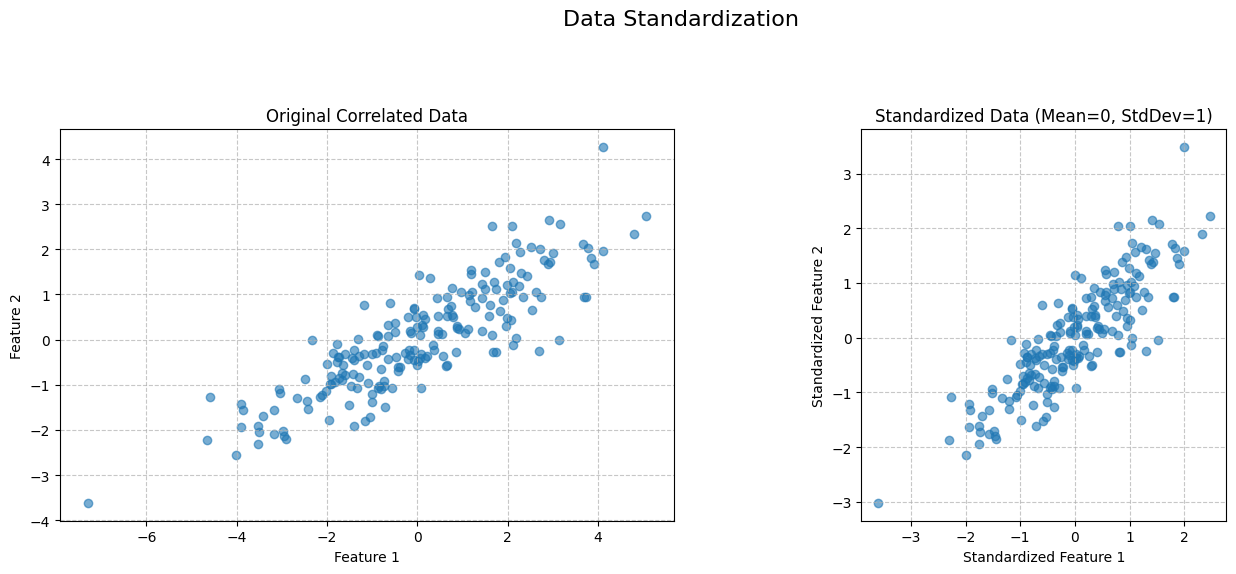

Original Data Mean (Feature 1, Feature 2): [0.04368846 0.04382877]
Standardized Data Mean (Feature 1, Feature 2): 0.00, 0.00
Original Data Std Dev (Feature 1, Feature 2): [2.03986699 1.2120676 ]
Standardized Data Std Dev (Feature 1, Feature 2): 1.00, 1.00


In [10]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Re-using our correlated data from the geometric intuition part
# X_correlated = ... (assuming it's still in memory or re-run the previous cell)

# Generate correlated 2D data if not already present (for independent execution)
if 'X_correlated' not in locals():
    np.random.seed(42)
    X_original = np.random.randn(200, 2)
    transformation = np.array([[2, 0.8], [0.8, 1]])
    X_correlated = X_original @ transformation

# --- Step 1: Standardize the Data ---
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X_correlated)

# Visualize original vs standardized data
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Data Standardization', fontsize=16)

axes[0].scatter(X_correlated[:, 0], X_correlated[:, 1], alpha=0.6)
axes[0].set_title('Original Correlated Data')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].set_aspect('equal', adjustable='box')
axes[0].grid(True, linestyle='--', alpha=0.7)

axes[1].scatter(X_standardized[:, 0], X_standardized[:, 1], alpha=0.6)
axes[1].set_title('Standardized Data (Mean=0, StdDev=1)')
axes[1].set_xlabel('Standardized Feature 1')
axes[1].set_ylabel('Standardized Feature 2')
axes[1].set_aspect('equal', adjustable='box')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

print(f"Original Data Mean (Feature 1, Feature 2): {np.mean(X_correlated, axis=0)}")
print(f"Standardized Data Mean (Feature 1, Feature 2): {np.mean(X_standardized, axis=0)[0]:.2f}, {np.mean(X_standardized, axis=0)[1]:.2f}")
print(f"Original Data Std Dev (Feature 1, Feature 2): {np.std(X_correlated, axis=0)}")
print(f"Standardized Data Std Dev (Feature 1, Feature 2): {np.std(X_standardized, axis=0)[0]:.2f}, {np.std(X_standardized, axis=0)[1]:.2f}")

#### Step 2: Calculate the Covariance Matrix

The covariance matrix is fundamental. For a dataset with $n$ features, the covariance matrix will be an $n \times n$ symmetric matrix where:

*   The diagonal elements represent the **variance** of each individual feature ($Var(X_i)$).
*   The off-diagonal elements represent the **covariance** between pairs of features ($Cov(X_i, X_j)$).

For standardized data, the covariance matrix is often very close to the correlation matrix.

$$ \Sigma = \frac{1}{m-1} X^T X $$

Where $X$ is the mean-centered (and standardized) data matrix, and $m$ is the number of samples.

In [6]:
# --- Step 2: Calculate the Covariance Matrix ---
cov_matrix_standardized = np.cov(X_standardized, rowvar=False)

print("Covariance Matrix of Standardized Data:")
print(cov_matrix_standardized)

Covariance Matrix of Standardized Data:
[[1.00502513 0.86708632]
 [0.86708632 1.00502513]]


#### Step 3: Compute Eigenvectors and Eigenvalues

This is the core of PCA. We perform an eigen-decomposition on the covariance matrix. The eigenvectors of the covariance matrix are the **Principal Components** (the new axes), and their corresponding eigenvalues tell us the **magnitude** of variance along those axes.

*   **Eigenvectors:** Represent the directions of maximum variance. They are orthogonal (perpendicular) to each other.
*   **Eigenvalues:** Quantify the amount of variance captured along each eigenvector. A larger eigenvalue means more variance along that principal component.

We sort the eigenvectors by their eigenvalues in descending order to get the most important principal components first.

In [7]:
# --- Step 3: Compute Eigenvectors and Eigenvalues ---
eigenvalues_pca, eigenvectors_pca = np.linalg.eig(cov_matrix_standardized)

# Sort eigenvalues and corresponding eigenvectors in descending order
sort_indices = np.argsort(eigenvalues_pca)[::-1]

# Sorted eigenvalues
sorted_eigenvalues = eigenvalues_pca[sort_indices]

# Sorted eigenvectors (each column is an eigenvector)
sorted_eigenvectors = eigenvectors_pca[:, sort_indices]

print("Eigenvalues (sorted):")
print(sorted_eigenvalues)
print("\nEigenvectors (sorted - each column is a PC):")
print(sorted_eigenvectors)

# Explained Variance Ratio
total_variance = np.sum(sorted_eigenvalues)
explained_variance_ratio = sorted_eigenvalues / total_variance

print("\nExplained Variance Ratio:")
print(explained_variance_ratio)
print(f"PC1 explains {explained_variance_ratio[0]*100:.2f}% of the total variance.")
print(f"PC2 explains {explained_variance_ratio[1]*100:.2f}% of the total variance.")

Eigenvalues (sorted):
[1.87211145 0.1379388 ]

Eigenvectors (sorted - each column is a PC):
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

Explained Variance Ratio:
[0.93137545 0.06862455]
PC1 explains 93.14% of the total variance.
PC2 explains 6.86% of the total variance.


#### Step 4: Select Principal Components (Dimensionality Reduction)

Here, you decide how many principal components to keep. This is where dimensionality reduction happens. You typically choose components that capture a significant amount of the total variance, often based on a cumulative explained variance threshold (e.g., 95%) or an 'elbow' in a scree plot.

In our 2D example, we have 2 principal components. If we wanted to reduce to 1 dimension, we would only keep PC1.

In [8]:
# --- Step 4: Select Principal Components ---
# For 2D data, we typically keep both to transform the axes, but if we were reducing,
# we might only select the first principal component.

# Let's say we decide to keep both principal components for now to observe the full transformation.
# The projection matrix (also called the feature vector or transformation matrix)
# consists of the selected eigenvectors as columns.
projection_matrix = sorted_eigenvectors

print("Projection Matrix (using all principal components):")
print(projection_matrix)

Projection Matrix (using all principal components):
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


#### Step 5: Transform the Data

Finally, you transform your original (standardized) data into the new, lower-dimensional space defined by the selected principal components. This is done by multiplying your standardized data matrix by the projection matrix.

$$ \text{Transformed Data} = \text{Standardized Data} \times \text{Projection Matrix} $$

Original (first 5 rows) Standardized Data:
[[ 0.41136427  0.17761241]
 [ 1.21091841  1.64788821]
 [-0.34281881 -0.38387993]
 [ 1.82790592  1.63932788]
 [-0.26893381  0.1016047 ]]

Transformed (first 5 rows) Data (onto Principal Components):
[[ 0.41646941 -0.16528753]
 [ 2.02148155  0.30898431]
 [-0.51385361 -0.0290346 ]
 [ 2.45170453 -0.13334481]
 [-0.11831955  0.26201029]]


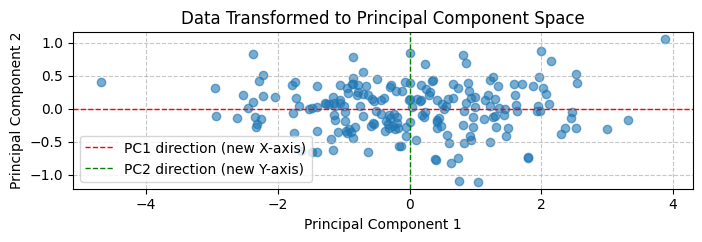

In [9]:
# --- Step 5: Transform the Data ---
X_pca = X_standardized @ projection_matrix

print("Original (first 5 rows) Standardized Data:")
print(X_standardized[:5])
print("\nTransformed (first 5 rows) Data (onto Principal Components):")
print(X_pca[:5])

# Visualize the transformed data
fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6)
ax.set_title('Data Transformed to Principal Component Space')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_aspect('equal', adjustable='box')
ax.grid(True, linestyle='--', alpha=0.7)

# Add PC axes for reference (they will now align with the standard axes)
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='PC1 direction (new X-axis)')
ax.axvline(0, color='green', linestyle='--', linewidth=1, label='PC2 direction (new Y-axis)')
ax.legend()

plt.show()

## 9. PCA with Scikit-learn (The Practical Approach)

While understanding the manual steps is crucial, in real-world applications, you'll almost always use a library like `scikit-learn` for PCA. It handles all the underlying mathematical computations for you, providing a streamlined way to apply dimensionality reduction.

Let's apply `PCA` from `sklearn.decomposition` to our correlated 2D data and compare the results with our manual calculation.

Scikit-learn PCA Explained Variance Ratio:
[0.93137545 0.06862455]
PC1 explains 93.14% of the total variance.
PC2 explains 6.86% of the total variance.

Scikit-learn PCA Components (Eigenvectors - each row is a PC):
[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]

Transformed Data (first 5 rows) using Scikit-learn PCA:
[[ 0.41646941 -0.16528753]
 [ 2.02148155  0.30898431]
 [-0.51385361 -0.0290346 ]
 [ 2.45170453 -0.13334481]
 [-0.11831955  0.26201029]]


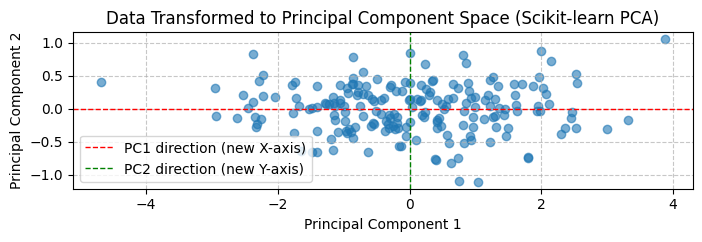

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Re-using our correlated data (ensure it's generated if running this cell independently)
if 'X_correlated' not in locals():
    np.random.seed(42)
    X_original = np.random.randn(200, 2)
    transformation = np.array([[2, 0.8], [0.8, 1]])
    X_correlated = X_original @ transformation

# --- Step 1: Standardize the Data (as Scikit-learn PCA internally centers, but scaling is good practice) ---
scaler = StandardScaler()
X_standardized_sklearn = scaler.fit_transform(X_correlated)

# --- Step 2: Apply PCA using scikit-learn ---
# n_components specifies how many principal components to keep.
# If None, all components are kept.
pca = PCA(n_components=2) # Keep both components for comparison

X_pca_sklearn = pca.fit_transform(X_standardized_sklearn)

print("Scikit-learn PCA Explained Variance Ratio:")
print(pca.explained_variance_ratio_)
print(f"PC1 explains {pca.explained_variance_ratio_[0]*100:.2f}% of the total variance.")
print(f"PC2 explains {pca.explained_variance_ratio_[1]*100:.2f}% of the total variance.")

print("\nScikit-learn PCA Components (Eigenvectors - each row is a PC):")
print(pca.components_)

print("\nTransformed Data (first 5 rows) using Scikit-learn PCA:")
print(X_pca_sklearn[:5])

# --- Visualize the transformed data from scikit-learn PCA ---
fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(X_pca_sklearn[:, 0], X_pca_sklearn[:, 1], alpha=0.6)
ax.set_title('Data Transformed to Principal Component Space (Scikit-learn PCA)')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_aspect('equal', adjustable='box')
ax.grid(True, linestyle='--', alpha=0.7)

# Add PC axes for reference
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='PC1 direction (new X-axis)')
ax.axvline(0, color='green', linestyle='--', linewidth=1, label='PC2 direction (new Y-axis)')
ax.legend()

plt.show()

### Comparison with Manual Steps:

*   **Explained Variance Ratio:** You'll notice that `pca.explained_variance_ratio_` from scikit-learn gives values very similar to our `explained_variance_ratio` from the manual calculation. This confirms that scikit-learn is calculating the eigenvalues correctly.
*   **Principal Components (Eigenvectors):** The `pca.components_` array contains the principal components (eigenvectors). These should be very similar to our `sorted_eigenvectors`. Note that the sign of eigenvectors can be flipped (e.g., `[0.707, 0.707]` vs `[-0.707, -0.707]`), but they still represent the same direction, just pointing in the opposite sense.
*   **Transformed Data:** The `X_pca_sklearn` will match `X_pca` from our manual steps (possibly with sign flips depending on the eigenvector directions, but the overall spread and relationship will be identical).

Scikit-learn handles the centering (and often scaling if a `StandardScaler` is used beforehand) and performs the eigen-decomposition efficiently, making it the preferred method for practical PCA applications.

## 10. Choosing the Number of Principal Components (The Art of Dimensionality Reduction)

One of the most critical decisions when applying PCA for dimensionality reduction is determining how many principal components to keep. Keeping too many might not achieve sufficient reduction, while keeping too few could lead to significant information loss.

There are a few common methods to guide this decision:

1.  **Explained Variance Ratio:** Each principal component explains a certain percentage of the total variance in the dataset. You typically sum these percentages to get the cumulative explained variance. A common heuristic is to select the number of components that explain a high percentage of variance, often between 90-99%.

2.  **Scree Plot:** This is a plot of the eigenvalues (or explained variance) against the number of principal components. You look for an 'elbow' in the plot – a point where the explained variance drops off sharply, and then levels out. The components before the elbow are usually considered significant.

3.  **Domain Knowledge:** Sometimes, prior knowledge about your data or the problem you're trying to solve can help you decide how many components are meaningful.

Let's visualize the explained variance for our 2D dataset, and consider what happens if we were working with higher-dimensional data.

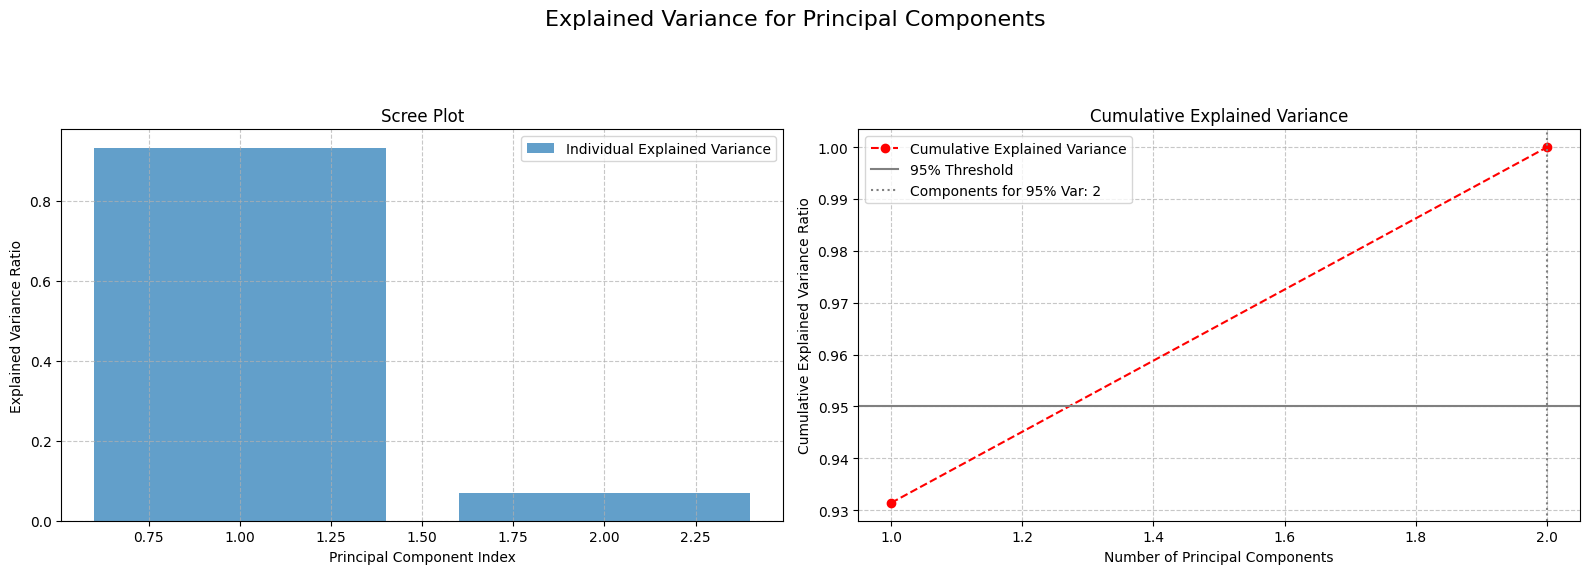

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Re-using our correlated data (ensure it's generated if running this cell independently)
if 'X_correlated' not in locals():
    np.random.seed(42)
    X_original = np.random.randn(200, 2)
    transformation = np.array([[2, 0.8], [0.8, 1]])
    X_correlated = X_original @ transformation

# Standardize the data
scaler = StandardScaler()
X_standardized_data = scaler.fit_transform(X_correlated)

# Apply PCA, keeping all components to calculate explained variance
pca_full = PCA() # By default, n_components = min(n_samples, n_features)
pca_full.fit(X_standardized_data)

# Explained variance ratio for each component
explained_variance_ratio = pca_full.explained_variance_ratio_

# Cumulative explained variance
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# --- Plotting Explained Variance and Cumulative Explained Variance ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Explained Variance for Principal Components', fontsize=16)

# Scree Plot (Explained Variance per Component)
ax1.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.7, align='center', label='Individual Explained Variance')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_xlabel('Principal Component Index')
ax1.set_title('Scree Plot')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Cumulative Explained Variance Plot
ax2.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--', color='red', label='Cumulative Explained Variance')
ax2.set_ylabel('Cumulative Explained Variance Ratio')
ax2.set_xlabel('Number of Principal Components')
ax2.set_title('Cumulative Explained Variance')
ax2.axhline(y=0.95, color='gray', linestyle='-', label='95% Threshold')
ax2.axvline(x=np.argmax(cumulative_explained_variance >= 0.95) + 1,
            color='gray', linestyle=':', label=f'Components for 95% Var: {np.argmax(cumulative_explained_variance >= 0.95) + 1}')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()